# <u>Métodos No Supervisados - Intro K-means</u>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

## Lectura de datos

Mall Customer Data https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python

In [2]:
df_customers = pd.read_csv(r"C:\Users\dg_su\OneDrive - Universidad Tecnologica del Peru\Estudios\Cursos\Analisis de Datos\Programa Data Science for Business\codigo\base de datos\Mall_Customers.csv")
df_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df_customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
#convertir datos categoricos a numericos
mapping = {'Male': 0, 'Female':1}

df_customers["Gender"] = df_customers["Gender"].map(mapping)

In [6]:
df_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [7]:
df_customers.columns = ['id', 'sexo', 'edad', 'ingreso', 'score']
df_customers.head()

,id,sexo,edad,ingreso,score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


## Clustering con dos variables

In [8]:
df_clustering = df_customers[['edad', 'score']]
df_clustering.head()

,edad,score
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [9]:
from sklearn.cluster import KMeans

In [10]:
model = KMeans(n_clusters = 3)

In [11]:
model.fit(df_clustering)

c:\Users\dg_su\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dg_su\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


KMeans(n_clusters=3)

In [12]:
model.predict(df_clustering)

array([0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2,
       1, 2, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 0,
       1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [13]:
df_clustering['cluster'] = model.predict(df_clustering)
df_clustering.head()

C:\Users\dg_su\AppData\Local\Temp\ipykernel_7252\4060935650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustering['cluster'] = model.predict(df_clustering)


,edad,score,cluster
0,19,39,0
1,21,81,2
2,20,6,1
3,23,77,2
4,31,40,0


In [14]:
df_clustering['cluster'].value_counts()

cluster
0    92
2    62
1    46
Name: count, dtype: int64

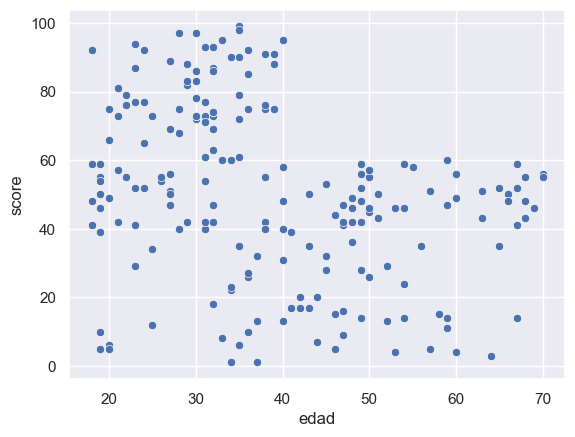

In [15]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score')
plt.show()

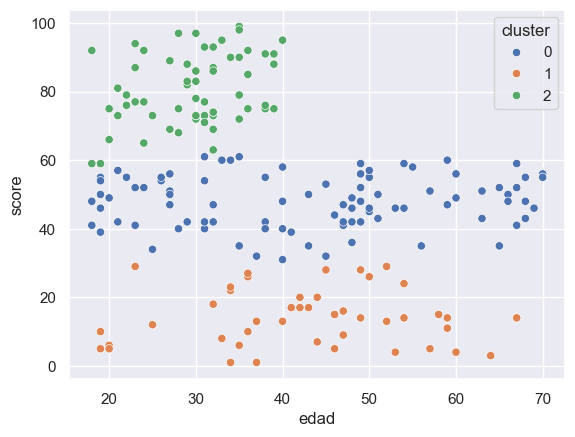

In [16]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score', hue = 'cluster', palette = 'deep')
plt.show()

## Preprocesamiento de variables

In [17]:
df_clustering = df_customers[['edad', 'score']]

In [18]:
df_clustering.head()

,edad,score
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [20]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_clustering),columns = df_clustering.columns) 
df_scaled.head()

,edad,score
0,0.019231,0.387755
1,0.057692,0.816327
2,0.038462,0.051020
3,0.096154,0.775510
4,0.250000,0.397959


## clustering con variables escaladas

In [21]:
model = KMeans(n_clusters = 3)

In [22]:
model.fit(df_scaled)

KMeans(n_clusters=3)

In [23]:
model.predict(df_scaled)

array([0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2, 1, 2, 0, 2,
       0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2,
       1, 2, 1, 0, 0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2, 1, 0, 1, 1, 1, 1,
       1, 2, 0, 2, 2, 2, 1, 1, 1, 1, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2,
       1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [24]:
df_clustering['cluster'] = model.predict(df_scaled)
df_clustering.head()

C:\Users\dg_su\AppData\Local\Temp\ipykernel_7252\931445122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustering['cluster'] = model.predict(df_scaled)


,edad,score,cluster
0,19,39,0
1,21,81,2
2,20,6,0
3,23,77,2
4,31,40,0


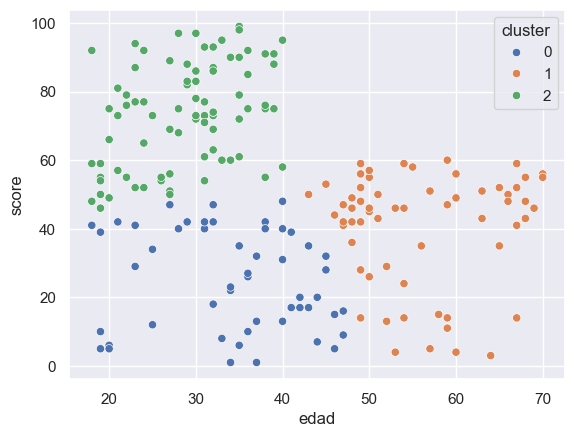

In [25]:
sns.scatterplot(data = df_clustering, x = 'edad', y = 'score', hue = 'cluster', palette = 'deep')
plt.show()

## Descriptivos de clustering

In [26]:
df_clustering.head()

,edad,score,cluster
0,19,39,0
1,21,81,2
2,20,6,0
3,23,77,2
4,31,40,0


In [27]:
df_clustering['cluster'].value_counts()

cluster
2    84
1    63
0    53
Name: count, dtype: int64

In [28]:
#puntos centrales de los clusters
df_clustering.groupby('cluster').mean()

,edad,score
cluster,,
0,34.566038,25.056604
1,55.968254,39.888889
2,28.714286,73.797619


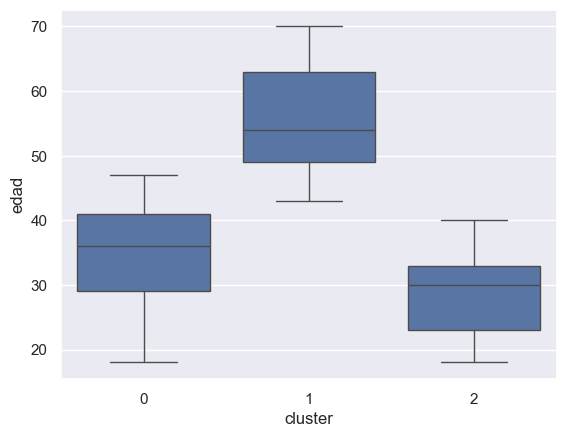

In [29]:
sns.boxplot(data = df_clustering, y = 'edad', x = 'cluster')
plt.show()

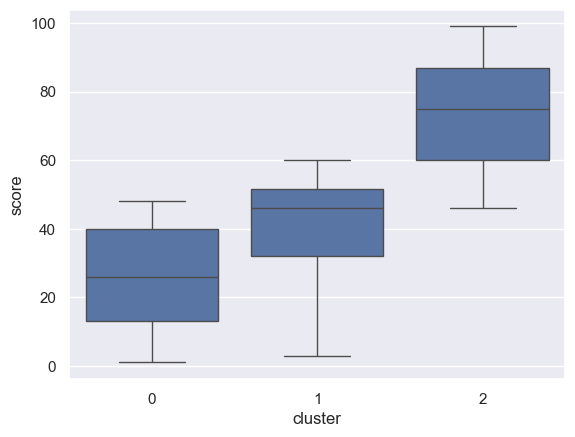

In [30]:
sns.boxplot(data = df_clustering, y = 'score', x = 'cluster')
plt.show()

## Clustering con más variables

In [31]:
df_customers.head()

,id,sexo,edad,ingreso,score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [44]:
df_clustering = df_customers[['edad', 'ingreso', 'score','sexo']]
df_clustering.head()

,edad,ingreso,score,sexo
0,19,15,39,0
1,21,15,81,0
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


In [45]:
scaler = MinMaxScaler()

In [46]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_clustering),columns = df_clustering.columns) 
df_scaled.head()

,edad,ingreso,score,sexo
0,0.019231,0.000000,0.387755,0.0
1,0.057692,0.000000,0.816327,0.0
2,0.038462,0.008197,0.051020,1.0
3,0.096154,0.008197,0.775510,1.0
4,0.250000,0.016393,0.397959,1.0


In [47]:
model = KMeans(n_clusters = 3)
model.fit(df_scaled)

KMeans(n_clusters=3)

In [48]:
df_customers['cluster'] = model.predict(df_scaled)

In [49]:
df_customers.head()

,id,sexo,edad,ingreso,score,cluster
0,1,0,19,15,39,1
1,2,0,21,15,81,1
2,3,1,20,16,6,2
3,4,1,23,16,77,0
4,5,1,31,17,40,0


In [50]:
df_customers['cluster'].value_counts()

cluster
1    88
0    57
2    55
Name: count, dtype: int64

In [51]:
df_customers.groupby('cluster').mean()

,id,sexo,edad,ingreso,score
cluster,,,,,
0,100.210526,1.0,28.438596,59.666667,67.684211
1,104.238636,0.0,39.806818,62.227273,48.511364
2,94.818182,1.0,48.109091,58.818182,34.781818


se puede observar que la variable ingreso no sirve para segmentar, ya que no tiene mucha variabilidad

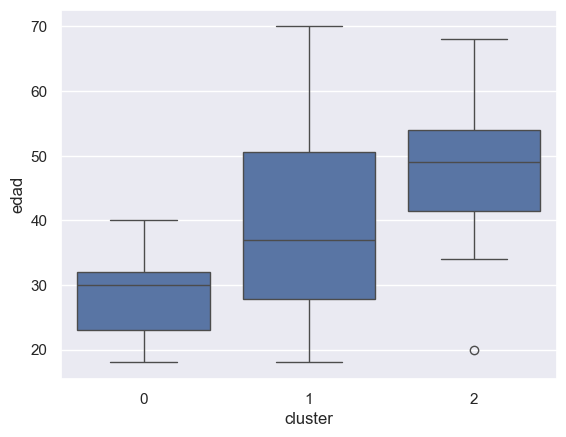

In [52]:
sns.boxplot(data = df_customers, y = 'edad', x = 'cluster')
plt.show()

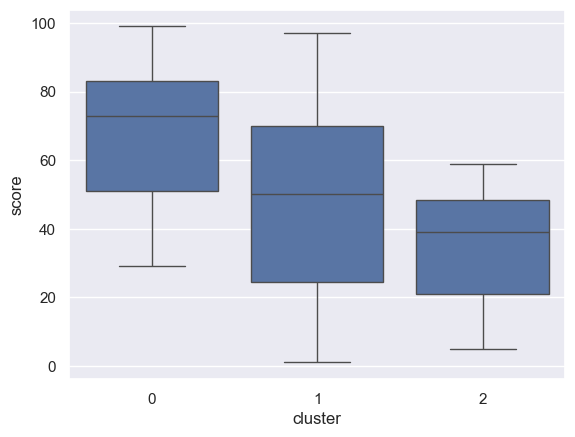

In [53]:
sns.boxplot(data = df_customers, y = 'score', x = 'cluster')
plt.show()

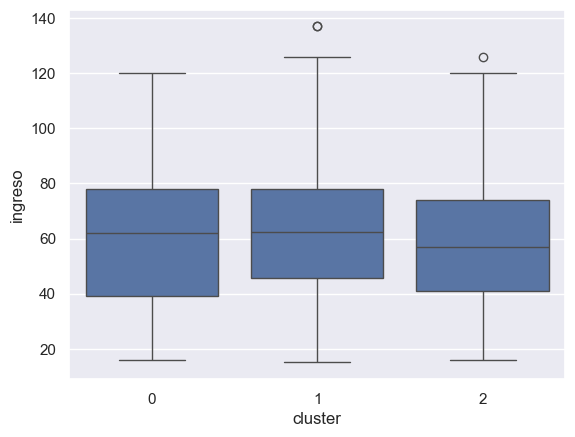

In [54]:
sns.boxplot(data = df_customers, y = 'ingreso', x = 'cluster')
plt.show()

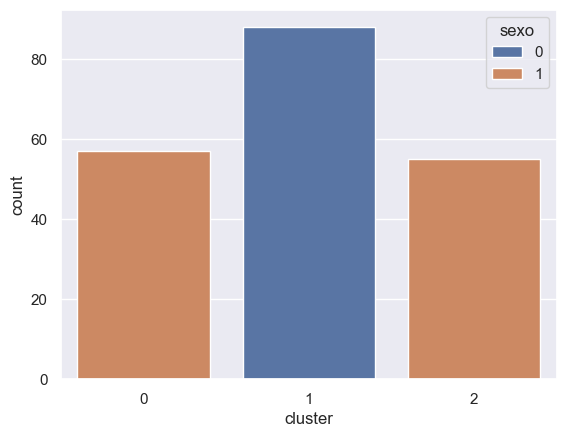

In [55]:
sns.countplot(data = df_customers, x = 'cluster', hue = 'sexo')
plt.show()